In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.append("../")

import pyaldata as pyal
import pandas as pd
import numpy as np


# from tools.reports.report_initial import run_initial_report
from tools import dataTools as dt
import pickle
import pathlib  
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import pyaldata as pyal
from tools.viz import mean_firing as firing
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from tools.params import Params
from tools.decoding import decodeTools as decode
from tools.dsp.preprocessing import preprocess
from tools.params import colors
from tools import dataTools as dt
import torch
from tools.viz import utilityTools as utility
# import sem from scipy.stats
from scipy.stats import sem
from tools import params
from tqdm import tqdm
from sklearn.model_selection import cross_val_score

In [4]:
sessions = [
    # 'M062_2025_03_19_14_00',
    # 'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    # 'M061_2025_03_04_10_00',
    # 'M061_2025_03_05_14_00',
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_12_14_00",  
    # "M063_2025_03_13_14_00",  
    # "M063_2025_03_14_15_30",
    # "M078_2025_08_05_15_30",
    # "M078_2025_08_06_15_00",
    # "M078_2025_08_07_13_30",
    # "M078_2025_08_08_10_30",# muscimol session
   
    # # "M066_2025_04_09_15_45" # bci session
    # "M103_2026_02_17_14_00", # control session
    # "M103_2026_02_17_14_00",# control session
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M103_2026_02_20_16_00",# muscimol session
    # "M106_2026_02_24_15_00",# control session
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
    # "M106_2026_02_27_16_00",# muscimol session
    # "M081_2026_01_28_16_00",
    # "M086_2025_12_09_16_00",
    # "M086_2025_12_10_15_00",
    # "M086_2025_12_11_15_00"
    
]




In [5]:
import sys
print(sys.executable)

import pyaldata
print(pyaldata.__file__)

/data/miniconda3/envs/eq/bin/python
/data/pyaldata/pyaldata/__init__.py


In [6]:
prep_df = dt.load_sessions(sessions, prep = True, only_trials = False)[0]

M062_2025_03_21_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
Repairing columns ['MotSen1_X', 'MotSen1_Y']
Extending index to 47999 in trial: free and id: 707, inserting NaN.
Extending index to 47989 in trial: free and id: 707, inserting NaN.
Extending index to 47990 in trial: free and id: 707, inserting NaN.
Extending index to 47991 in trial: free and id: 707, inserting NaN.
Extending index to 47992 in trial: free and id: 707, inserting NaN.
Extending index to 47993 in trial: free and id: 707, inserting NaN.
Extending index to 47994 in trial: free and id: 707, inserting NaN.
Extending index to 47995 in trial: free and id: 707, inserting NaN.
Exte

In [52]:
window_size_s = 60
field = "VAL_rates"
meta_df, X = dt.build_window_tensor_sliding_session(prep_df,window_size_s=window_size_s,field = field, overlap_pct=0)

In [53]:
X_mean_per_window = X.mean(axis=1)

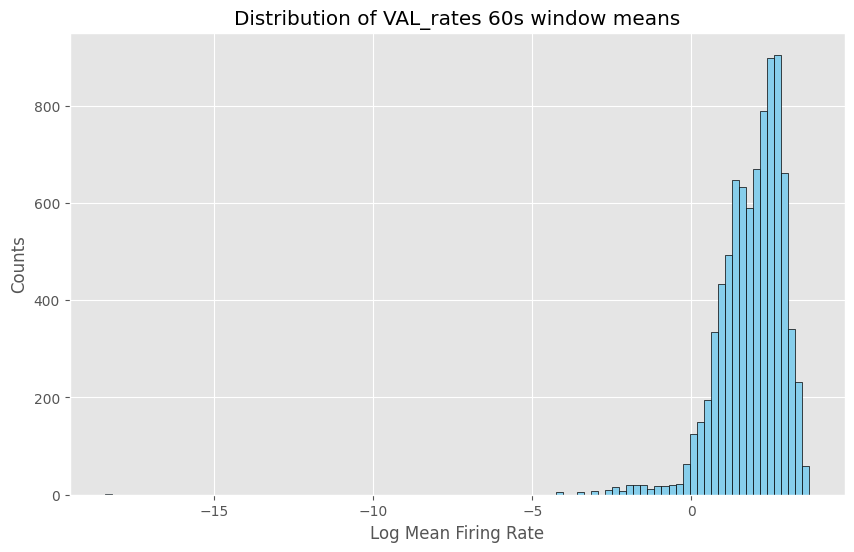

In [54]:
fig,ax = plt.subplots(figsize=(10,6))
# log normalize the histogram
ax.hist(np.log(X_mean_per_window.flatten() + 1e-8), bins=100, color='skyblue', edgecolor='black')
ax.set_title(f'Distribution of {field} {window_size_s}s window means')
ax.set_xlabel('Log Mean Firing Rate')
ax.set_ylabel('Counts')
plt.show()

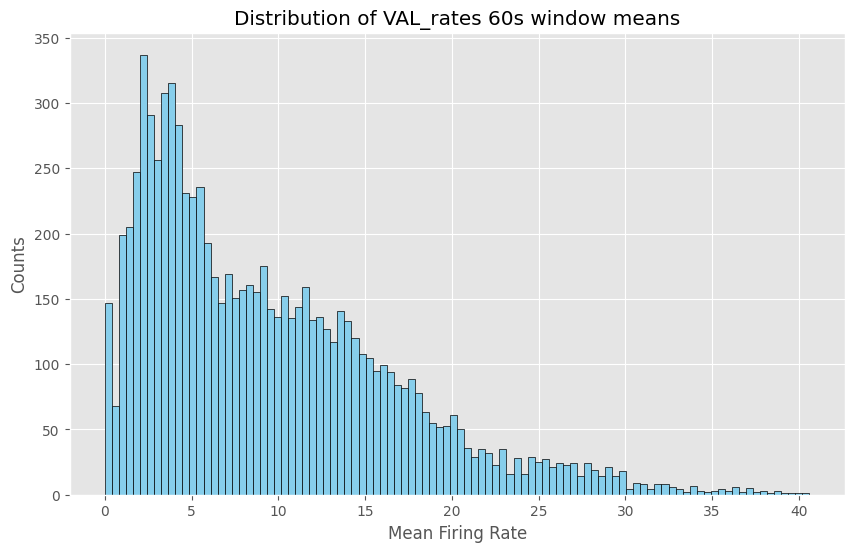

In [55]:
fig,ax = plt.subplots(figsize=(10,6))
# log normalize the histogram
ax.hist(X_mean_per_window.flatten(), bins=100, color='skyblue', edgecolor='black')
ax.set_title(f'Distribution of {field} {window_size_s}s window means')
ax.set_xlabel('Mean Firing Rate')
ax.set_ylabel('Counts')
plt.show()

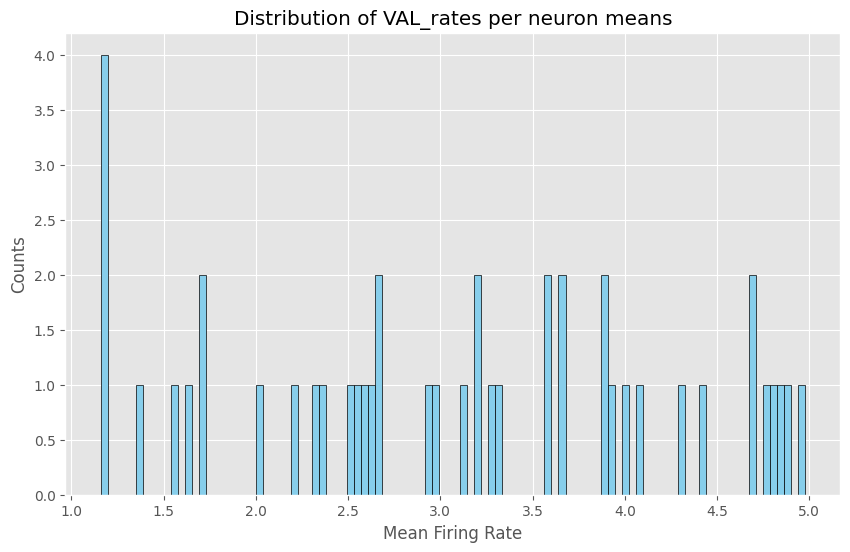

In [56]:
fig,ax = plt.subplots(figsize=(10,6))
# log normalize the histogram
ax.hist(X_mean_per_window.mean(axis = 0)[X_mean_per_window.mean(axis = 0)<5], bins=100, color='skyblue', edgecolor='black')
ax.set_title(f'Distribution of {field} per neuron means')
ax.set_xlabel('Mean Firing Rate')
ax.set_ylabel('Counts')
plt.show()

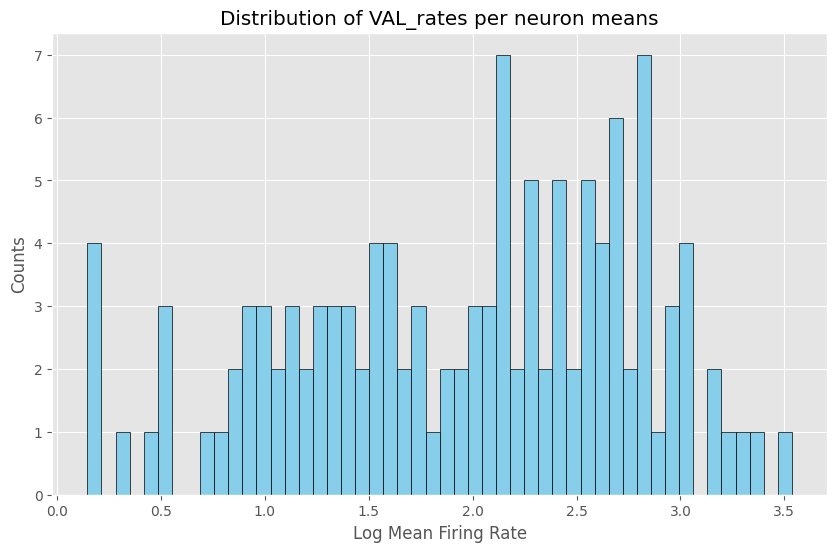

In [57]:
fig,ax = plt.subplots(figsize=(10,6))
# log normalize the histogram
ax.hist(np.log(X_mean_per_window.mean(axis=0) + 1e-8), bins=50, color='skyblue', edgecolor='black')
ax.set_title(f'Distribution of {field} per neuron means')
ax.set_xlabel('Log Mean Firing Rate')
ax.set_ylabel('Counts')
plt.show()

In [60]:
threshold_hz = 1
n_windows, n_neurons = X_mean_per_window.shape
window_fr = X_mean_per_window.T
active = window_fr > threshold_hz
presence_ratio = active.float().mean(axis=1)

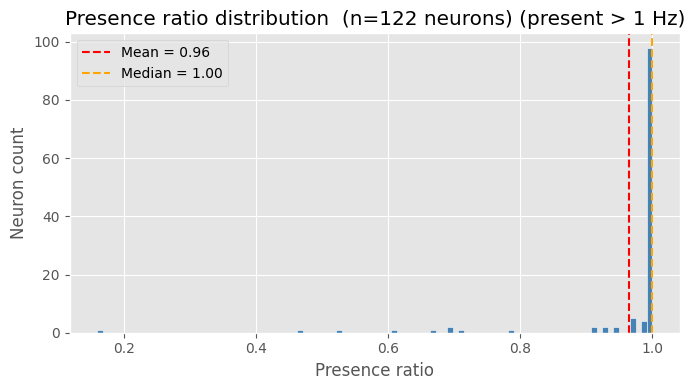

In [61]:
fig, ax = plt.subplots(figsize=(7, 4))

pr = presence_ratio.numpy() 

ax.hist(pr, bins=100, color='steelblue', edgecolor='white', linewidth=0.4)

ax.axvline(pr.mean(), color='red',    linestyle='--', label=f'Mean = {pr.mean():.2f}')
ax.axvline(np.median(pr), color='orange', linestyle='--', label=f'Median = {np.median(pr):.2f}')
# ax.axvline(0.9, color='black', linestyle=':', linewidth=1.5, label='Threshold = 0.9')

ax.set_xlabel('Presence ratio')
ax.set_ylabel('Neuron count')
ax.set_title(f'Presence ratio distribution  (n={len(pr)} neurons) (present > {threshold_hz} Hz)')
ax.legend()

plt.tight_layout()
plt.show()

In [1]:
def get_activity_bounds(active_matrix):
    """
    For each neuron, find:
      - first_active  : first window where neuron fires
      - last_active   : last window where neuron fires
      - first_dropout : first silent window after first_active
    """
    n_neurons, n_windows = active_matrix.shape
    
    first_active  = np.full(n_neurons, n_windows, dtype=int)
    last_active   = np.full(n_neurons, -1, dtype=int)
    first_dropout = np.full(n_neurons, n_windows, dtype=int)
    
    for i in range(n_neurons):
        active_wins = np.where(active_matrix[i])[0]
        silent_wins = np.where(~active_matrix[i])[0]
        
        if len(active_wins) > 0:
            first_active[i] = active_wins[0]
            last_active[i]  = active_wins[-1]
        
        if len(silent_wins) > 0:
            # first silent window that occurs after the neuron first appears
            late_silent = silent_wins[silent_wins > first_active[i]]
            if len(late_silent) > 0:
                first_dropout[i] = late_silent[0]
    
    return first_active, last_active, first_dropout

In [62]:
first_active, last_active, first_dropout = get_activity_bounds(active)

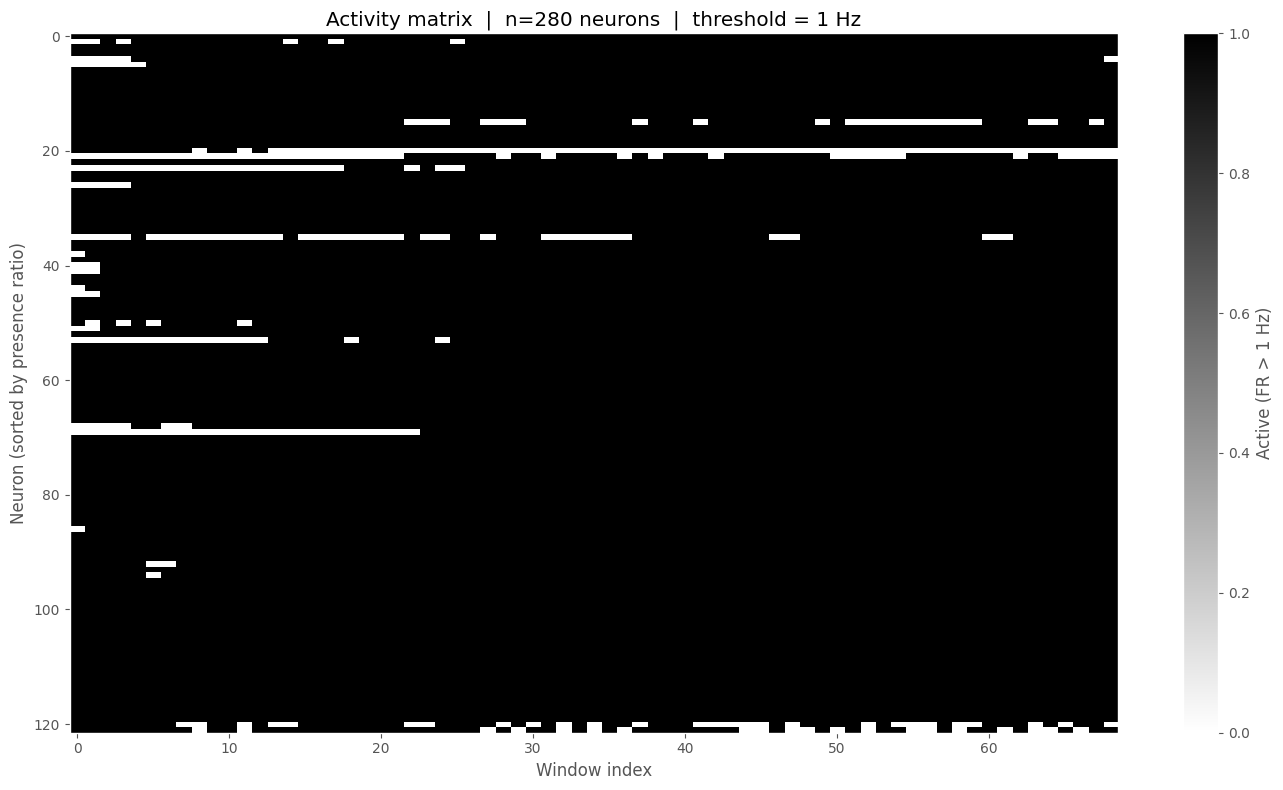

In [63]:
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(active.numpy().astype(float), aspect='auto',
               interpolation='none', cmap='binary', vmin=0, vmax=1)

plt.colorbar(im, ax=ax, label=f'Active (FR > {threshold_hz} Hz)')

ax.set_xlabel('Window index')
ax.set_ylabel('Neuron (sorted by presence ratio)')
ax.set_title(f'Activity matrix  |  n={len(order)} neurons  |  threshold = {threshold_hz} Hz')
ax.grid(False)
plt.tight_layout()
plt.show()

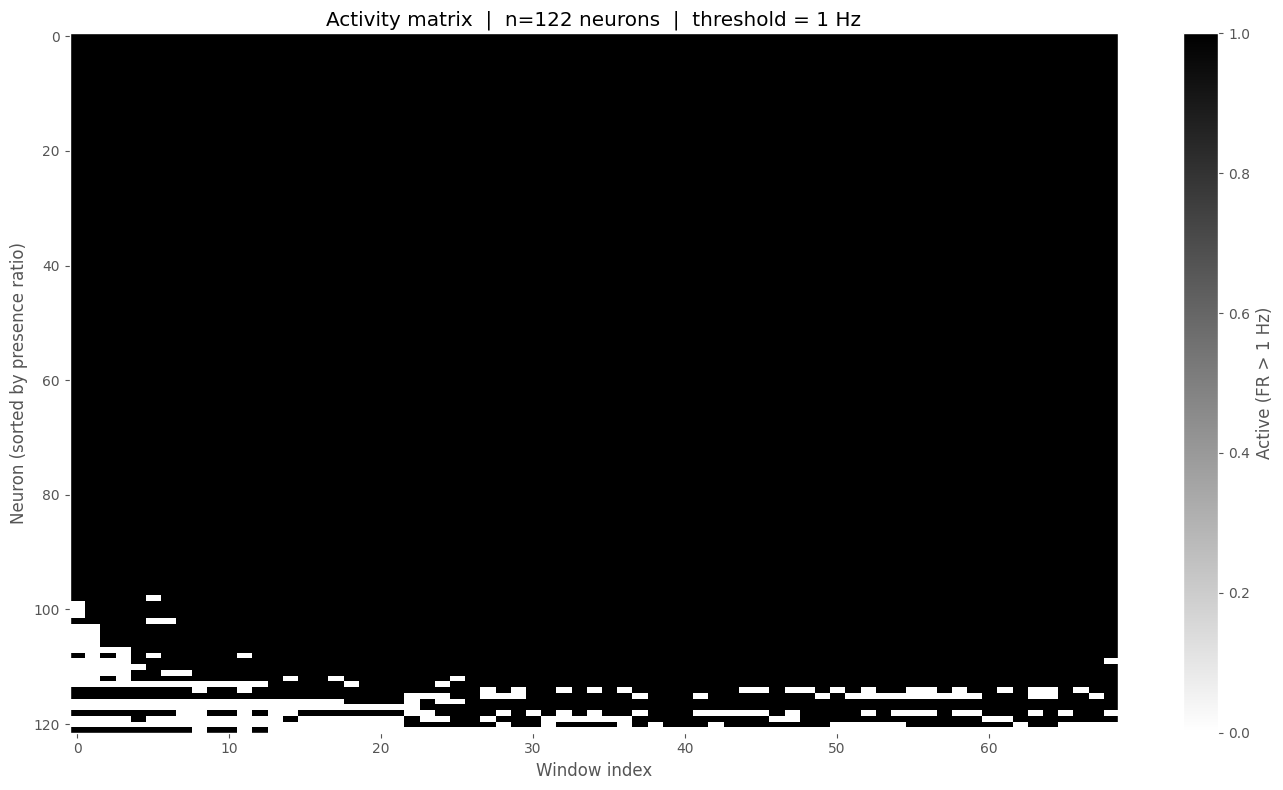

In [64]:
order = np.argsort(presence_ratio.numpy())[::-1]  # highest presence ratio at top
active_sorted = active.numpy()[order]

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(active_sorted.astype(float), aspect='auto',
               interpolation='none', cmap='binary', vmin=0, vmax=1)

plt.colorbar(im, ax=ax, label=f'Active (FR > {threshold_hz} Hz)')

ax.set_xlabel('Window index')
ax.set_ylabel('Neuron (sorted by presence ratio)')
ax.set_title(f'Activity matrix  |  n={len(order)} neurons  |  threshold = {threshold_hz} Hz')
ax.grid(False)
plt.tight_layout()
plt.show()

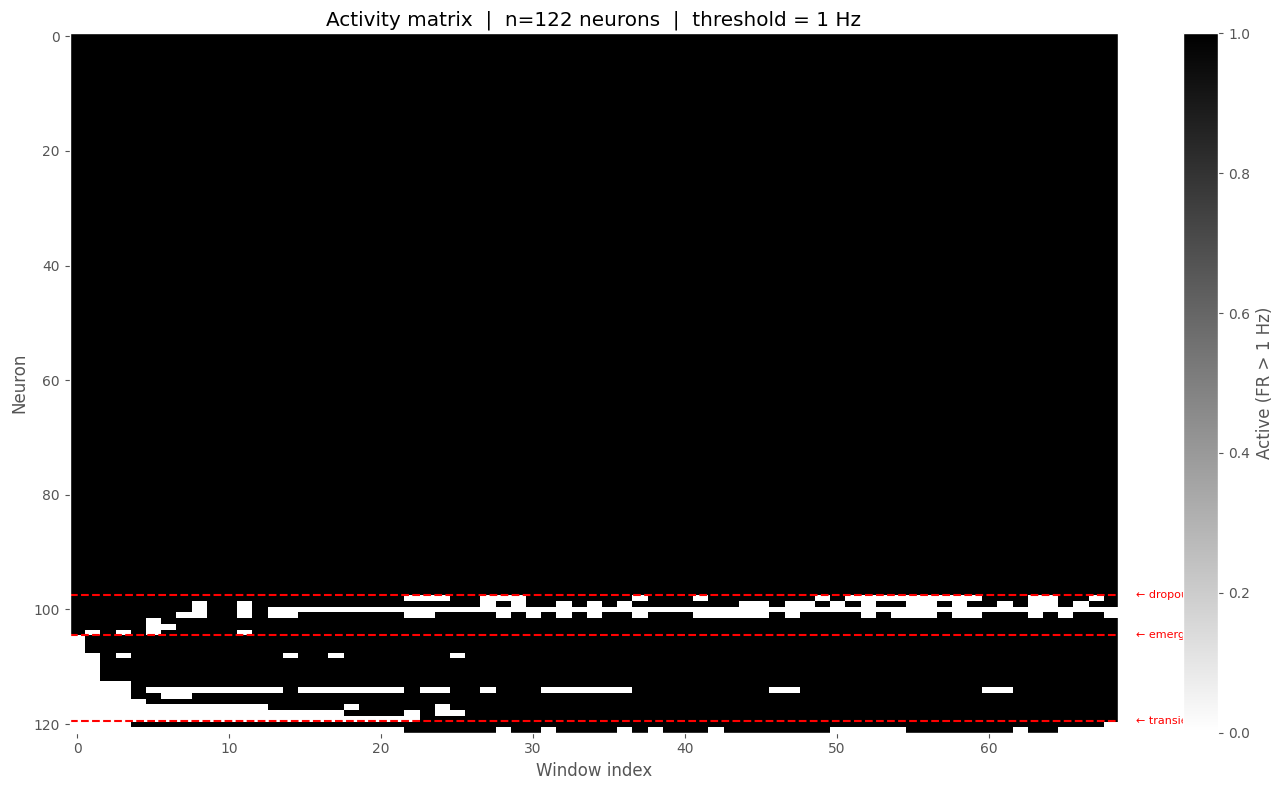

In [65]:
first_active, last_active, first_dropout = get_activity_bounds(active.numpy())

stable       = (first_active == 0) & (last_active == n_windows - 1) & (first_dropout == n_windows)
dropout_only = (first_active == 0) & (first_dropout < n_windows)
emerges_only = (first_active > 0)  & (last_active == n_windows - 1)
transient    = ~stable & ~dropout_only & ~emerges_only

# sort within each group
stable_idx       = np.where(stable)[0]                                          # no meaningful sort
dropout_idx      = np.where(dropout_only)[0][np.argsort(first_dropout[dropout_only])[::-1]]  # latest dropout first
emerges_idx      = np.where(emerges_only)[0][np.argsort(first_active[emerges_only])]         # earliest emergence first
transient_idx    = np.where(transient)[0]                                       # sorted by presence ratio

order = np.concatenate([stable_idx, dropout_idx, emerges_idx, transient_idx])

active_sorted = active.numpy()[order]

# group boundary positions for horizontal lines
b_dropout  = len(stable_idx)
b_emerges  = b_dropout + len(dropout_idx)
b_transient = b_emerges + len(emerges_idx)

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(active_sorted.astype(float), aspect='auto',
               interpolation='none', cmap='binary', vmin=0, vmax=1)

# group boundary lines
for b, label in zip([b_dropout, b_emerges, b_transient],
                    ['← dropout', '← emerges', '← transient']):
    ax.axhline(b - 0.5, color='red', linewidth=1.5, linestyle='--')
    ax.text(n_windows * 1.01, b - 0.5, label, va='center',
            fontsize=8, color='red', clip_on=False)

# group labels on y axis
# for pos, label, count in [
#     (b_dropout / 2,                          'stable',    len(stable_idx)),
#     ((b_dropout + b_emerges) / 2,            'dropout',   len(dropout_idx)),
#     ((b_emerges + b_transient) / 2,          'emerges',   len(emerges_idx)),
#     ((b_transient + len(order)) / 2,         'transient', len(transient_idx)),
# ]:
#     ax.text(-n_windows * 0.02, pos, f'{label}\n(n={count})',
#             va='center', ha='right', fontsize=8, clip_on=False)

plt.colorbar(im, ax=ax, label=f'Active (FR > {threshold_hz} Hz)')
ax.set_xlabel('Window index')
ax.set_ylabel('Neuron')
ax.set_title(f'Activity matrix  |  n={len(order)} neurons  |  threshold = {threshold_hz} Hz')
ax.grid(False)
plt.tight_layout()
plt.show()

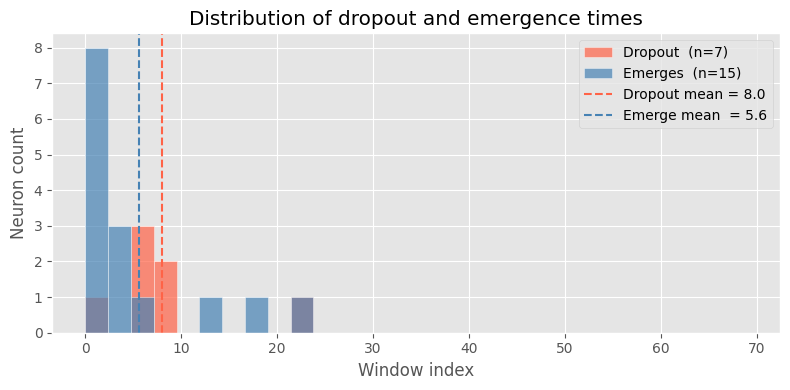

In [66]:
fig, ax = plt.subplots(figsize=(8, 4))

dropout_times = first_dropout[dropout_only]
emerge_times  = first_active[emerges_only]

bins = np.linspace(0, n_windows, 30)

ax.hist(dropout_times, bins=bins, color='tomato',    alpha=0.7,
        edgecolor='white', linewidth=0.4, label=f'Dropout  (n={len(dropout_times)})')
ax.hist(emerge_times,  bins=bins, color='steelblue', alpha=0.7,
        edgecolor='white', linewidth=0.4, label=f'Emerges  (n={len(emerge_times)})')

ax.axvline(dropout_times.mean(), color='tomato',    linestyle='--',
           linewidth=1.5, label=f'Dropout mean = {dropout_times.mean():.1f}')
ax.axvline(emerge_times.mean(),  color='steelblue', linestyle='--',
           linewidth=1.5, label=f'Emerge mean  = {emerge_times.mean():.1f}')

ax.set_xlabel('Window index')
ax.set_ylabel('Neuron count')
ax.set_title('Distribution of dropout and emergence times')
ax.legend()

plt.tight_layout()
plt.show()

In [37]:
meta_df

,window_index,start_frame,end_frame,bin_size,window_size_samples,step_size_samples,window_size_s,step_size_s,overlap_pct
0,0,0,5999,0.01,6000,6000,60.0,60.0,0
1,1,6000,11999,0.01,6000,6000,60.0,60.0,0
2,2,12000,17999,0.01,6000,6000,60.0,60.0,0
3,3,18000,23999,0.01,6000,6000,60.0,60.0,0
4,4,24000,29999,0.01,6000,6000,60.0,60.0,0
...,...,...,...,...,...,...,...,...,...
64,64,384000,389999,0.01,6000,6000,60.0,60.0,0
65,65,390000,395999,0.01,6000,6000,60.0,60.0,0
66,66,396000,401999,0.01,6000,6000,60.0,60.0,0
67,67,402000,407999,0.01,6000,6000,60.0,60.0,0


In [79]:
def plot_area_activity_figure(prep_df, area, window_size_s, threshold_hz, overlap_pct=0):
    """
    Build a single figure with the notebook's summary plots for one area.

    Parameters
    ----------
    prep_df : pandas.DataFrame
        Preprocessed session dataframe.
    area : str
        Area prefix used to select the rates field, e.g. "MOp" -> "MOp_rates".
    window_size_s : int
        Sliding window size in seconds.
    threshold_hz : float
        Activity threshold used to define active windows.
    overlap_pct : float, optional
        Window overlap percentage passed to the sliding tensor builder.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure containing the summary subplots.
    axes : numpy.ndarray
        Axes array for the subplots.
    """
    field = f"{area}_rates"
    meta_df, X = dt.build_window_tensor_sliding_session(
        prep_df,
        window_size_s=window_size_s,
        field=field,
        overlap_pct=overlap_pct,
    )

    X_mean_per_window = X.mean(axis=1)
    n_windows, n_neurons = X_mean_per_window.shape
    window_fr = X_mean_per_window.T
    active = window_fr > threshold_hz
    presence_ratio = active.float().mean(axis=1)
    pr = presence_ratio.numpy() if hasattr(presence_ratio, "numpy") else np.asarray(presence_ratio)

    def get_activity_bounds(active_matrix):
        n_neurons_local, n_windows_local = active_matrix.shape
        first_active = np.full(n_neurons_local, n_windows_local, dtype=int)
        last_active = np.full(n_neurons_local, -1, dtype=int)
        first_dropout = np.full(n_neurons_local, n_windows_local, dtype=int)

        for i in range(n_neurons_local):
            active_wins = np.where(active_matrix[i])[0]
            silent_wins = np.where(~active_matrix[i])[0]

            if len(active_wins) > 0:
                first_active[i] = active_wins[0]
                last_active[i] = active_wins[-1]

            if len(silent_wins) > 0:
                late_silent = silent_wins[silent_wins > first_active[i]]
                if len(late_silent) > 0:
                    first_dropout[i] = late_silent[0]

        return first_active, last_active, first_dropout

    first_active, last_active, first_dropout = get_activity_bounds(active.numpy())

    stable = (first_active == 0) & (last_active == n_windows - 1) & (first_dropout == n_windows)
    dropout_only = (first_active == 0) & (first_dropout < n_windows)
    emerges_only = (first_active > 0) & (last_active == n_windows - 1)
    transient = ~stable & ~dropout_only & ~emerges_only

    stable_idx = np.where(stable)[0]
    dropout_idx = np.where(dropout_only)[0]
    if len(dropout_idx) > 0:
        dropout_idx = dropout_idx[np.argsort(first_dropout[dropout_only])[::-1]]
    emerges_idx = np.where(emerges_only)[0]
    if len(emerges_idx) > 0:
        emerges_idx = emerges_idx[np.argsort(first_active[emerges_only])]
    transient_idx = np.where(transient)[0]

    order = np.concatenate([stable_idx, dropout_idx, emerges_idx, transient_idx])
    active_sorted = active.numpy()[order]

    fig, axes = plt.subplots(3, 2, figsize=(16, 14), constrained_layout=True)
    axes = axes.ravel()

    axes[1].hist(np.sqrt(X_mean_per_window.flatten()), bins=100, color='skyblue', edgecolor='black')
    axes[1].set_title(f'Sqrt distribution of {field} {window_size_s}s window means')
    axes[1].set_xlabel('Sqrt Mean Firing Rate')
    axes[1].set_ylabel('Counts')

    axes[0].hist(X_mean_per_window.flatten(), bins=100, color='skyblue', edgecolor='black')
    axes[0].set_title(f'Distribution of {field} {window_size_s}s window means')
    axes[0].set_xlabel('Mean Firing Rate')
    axes[0].set_ylabel('Counts')

    axes[2].hist(np.log(X_mean_per_window.mean(axis=0) + 1e-8), bins=50, color='skyblue', edgecolor='black')
    axes[2].set_title(f'Distribution of {field} per neuron means')
    axes[2].set_xlabel(' Mean Firing Rate')
    axes[2].set_ylabel('Counts')

    axes[3].hist(pr, bins=100, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[3].axvline(pr.mean(), color='red', linestyle='--', label=f'Mean = {pr.mean():.2f}')
    axes[3].axvline(np.median(pr), color='orange', linestyle='--', label=f'Median = {np.median(pr):.2f}')
    axes[3].set_xlabel('Presence ratio')
    axes[3].set_ylabel('Neuron count')
    axes[3].set_title(f'Presence ratio distribution (present > {threshold_hz} Hz)')
    axes[3].legend()

    im = axes[4].imshow(active_sorted.astype(float), aspect='auto', interpolation='none', cmap='binary', vmin=0, vmax=1)
    axes[4].set_xlabel('Window index')
    axes[4].set_ylabel('Neuron (grouped)')
    axes[4].set_title(f'Activity matrix | n={len(order)} neurons')
    axes[4].grid(False)
    fig.colorbar(im, ax=axes[4], label=f'Active (FR > {threshold_hz} Hz)')

    dropout_times = first_dropout[dropout_only]
    emerge_times = first_active[emerges_only]
    if len(dropout_times) > 0 or len(emerge_times) > 0:
        bins = np.linspace(0, n_windows, 30)
        if len(dropout_times) > 0:
            axes[5].hist(dropout_times, bins=bins, color='tomato', alpha=0.7, edgecolor='white', linewidth=0.4, label=f'Dropout (n={len(dropout_times)})')
        if len(emerge_times) > 0:
            axes[5].hist(emerge_times, bins=bins, color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.4, label=f'Emerges (n={len(emerge_times)})')
        if len(dropout_times) > 0:
            axes[5].axvline(dropout_times.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Dropout mean = {dropout_times.mean():.1f}')
        if len(emerge_times) > 0:
            axes[5].axvline(emerge_times.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'Emerge mean = {emerge_times.mean():.1f}')
        axes[5].set_xlabel('Window index')
        axes[5].set_ylabel('Neuron count')
        axes[5].set_title('Distribution of dropout and emergence times')
        axes[5].legend()
    else:
        axes[5].text(0.5, 0.5, 'No dropout or emergence events for the chosen threshold', ha='center', va='center')
        axes[5].set_axis_off()

    fig.suptitle(f'{area} activity summary | window_size_s={window_size_s} | threshold_hz={threshold_hz}', y=1.02)
    return fig, axes

In [96]:
def get_rate_areas(prep_df):
    """Return area prefixes for columns that end with '_rates'."""
    return [col[:-6] for col in prep_df.columns if col.endswith('_rates')]


def compute_full_participation_sweep(
    prep_df,
    areas=None,
    window_size_s=60,
    thresholds=np.arange(0.0, 1.01, 0.1),
    overlap_pct=0,
    participation_ratio_threshold=1.0,
):
    """
    Compute, for each area and threshold, how many neurons meet a participation ratio.

    A neuron is counted as meeting the participation_ratio_threshold if it is active
    in at least (participation_ratio_threshold * n_windows) sliding windows.
    E.g., participation_ratio_threshold=1.0 means 100% (active in all windows),
          participation_ratio_threshold=0.9 means 90% participation.

    Returns a tidy DataFrame with columns:
        area, threshold_hz, n_qualifying, n_neurons, n_windows, participation_ratio_threshold
    """
    if areas is None:
        areas = get_rate_areas(prep_df)

    records = []
    threshold_values = np.asarray(thresholds, dtype=float)

    for area in areas:
        field = f"{area}_rates"
        if field not in prep_df.columns:
            continue

        _, X = dt.build_window_tensor_sliding_session(
            prep_df,
            window_size_s=window_size_s,
            field=field,
            overlap_pct=overlap_pct,
        )

        X_mean_per_window = X.mean(axis=1)
        window_fr = X_mean_per_window.T
        window_fr = window_fr.detach().cpu().numpy() if hasattr(window_fr, "detach") else np.asarray(window_fr)

        n_windows, n_neurons = X_mean_per_window.shape

        for threshold_hz in threshold_values:
            active = window_fr > threshold_hz
            n_active_windows_per_neuron = active.sum(axis=1)
            min_windows_required = participation_ratio_threshold * n_windows
            n_qualifying = np.sum(n_active_windows_per_neuron >= min_windows_required)
            records.append(
                {
                    "area": area,
                    "threshold_hz": float(threshold_hz),
                    "n_qualifying": int(n_qualifying),
                    "n_neurons": int(n_neurons),
                    "n_windows": int(n_windows),
                    "window_size_s": int(window_size_s),
                    "participation_ratio_threshold": float(participation_ratio_threshold),
                    "field": field,
                }
            )

    return pd.DataFrame.from_records(records)


def plot_full_participation_sweep(sweep_df):
    """Plot the threshold sweep returned by compute_full_participation_sweep."""
    fig, ax = plt.subplots(figsize=(9, 5))
    
    participation_pct = (sweep_df["participation_ratio_threshold"].iloc[0] * 100)

    for area, area_df in sweep_df.sort_values("threshold_hz").groupby("area"):
        ax.plot(
            area_df["threshold_hz"],
            area_df["n_qualifying"],
            marker="o",
            linewidth=2,
            label=area,
        )

    ax.set_xlabel("Threshold (Hz)")
    ax.set_ylabel(f"Neurons with ≥{participation_pct:.0f}% participation ratio")
    ax.set_title(f"Neurons across threshold sweep (participation ≥ {participation_pct:.0f}%)")
    ax.set_xticks(np.arange(0.0, 1.01, 0.1))
    ax.grid(True, alpha=0.3)
    ax.legend(title="Area")
    plt.tight_layout()
    return fig, ax

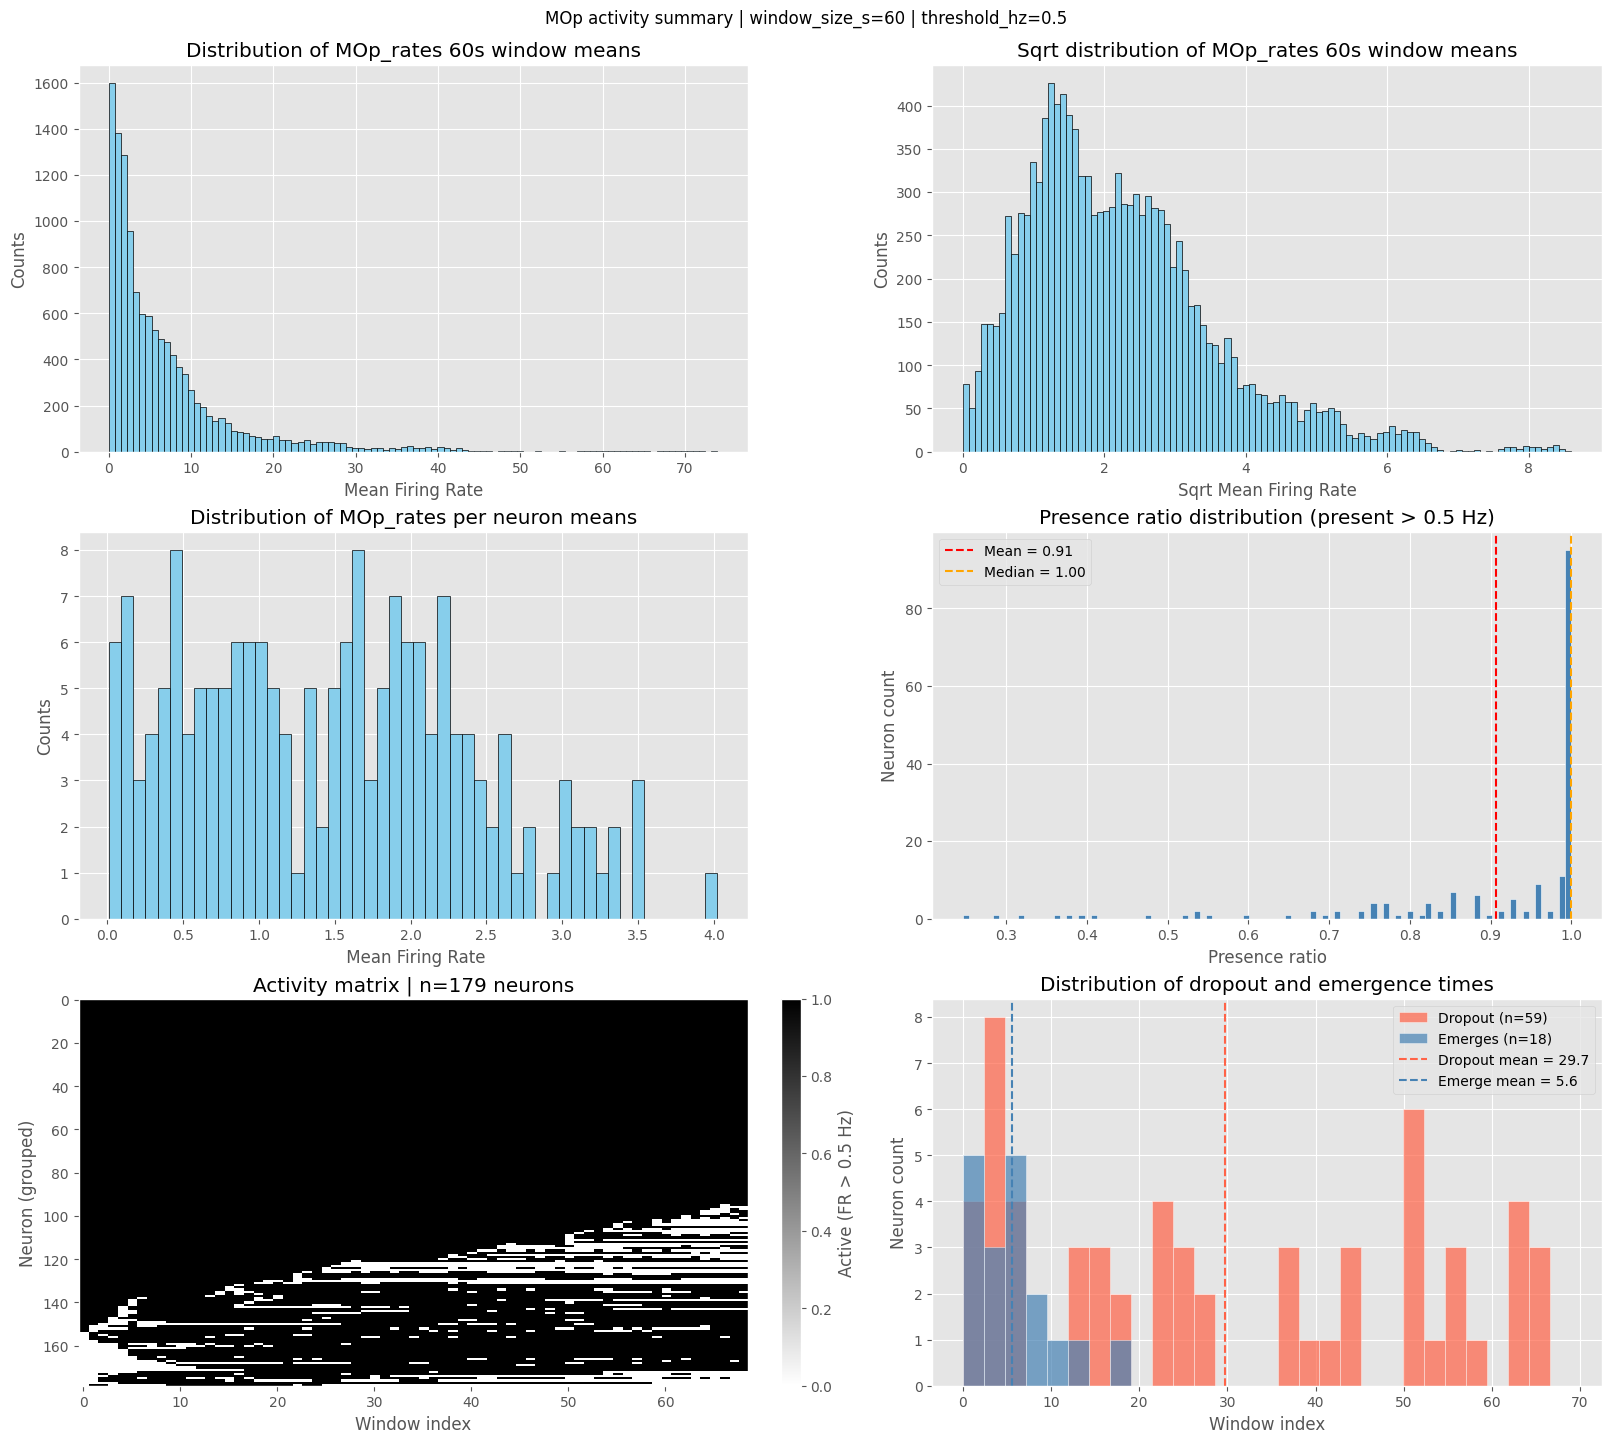

In [80]:
fig, axes = plot_area_activity_figure(prep_df, area='MOp', window_size_s=60, threshold_hz=0.5)

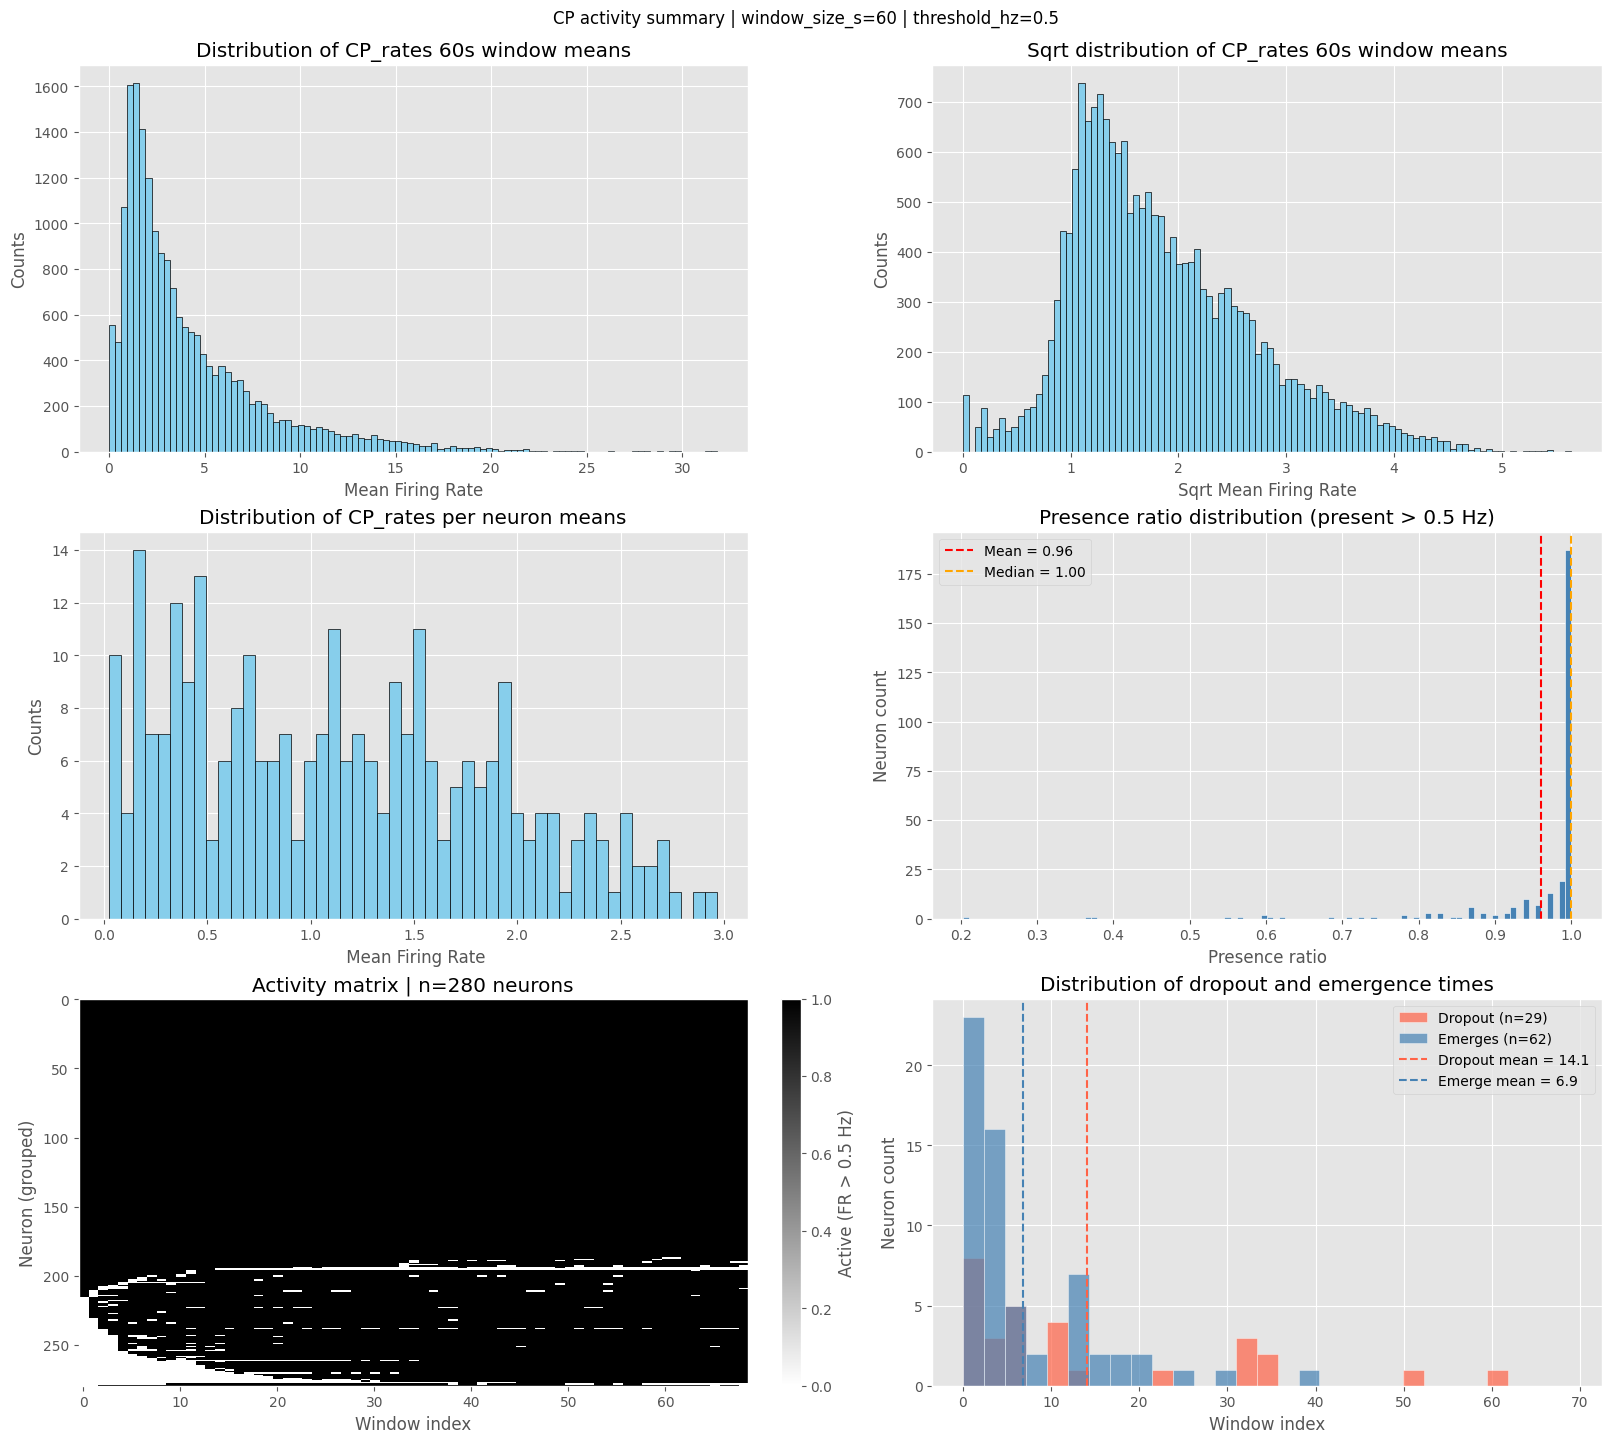

In [81]:
fig, axes = plot_area_activity_figure(prep_df, area='CP', window_size_s=60, threshold_hz=0.5)

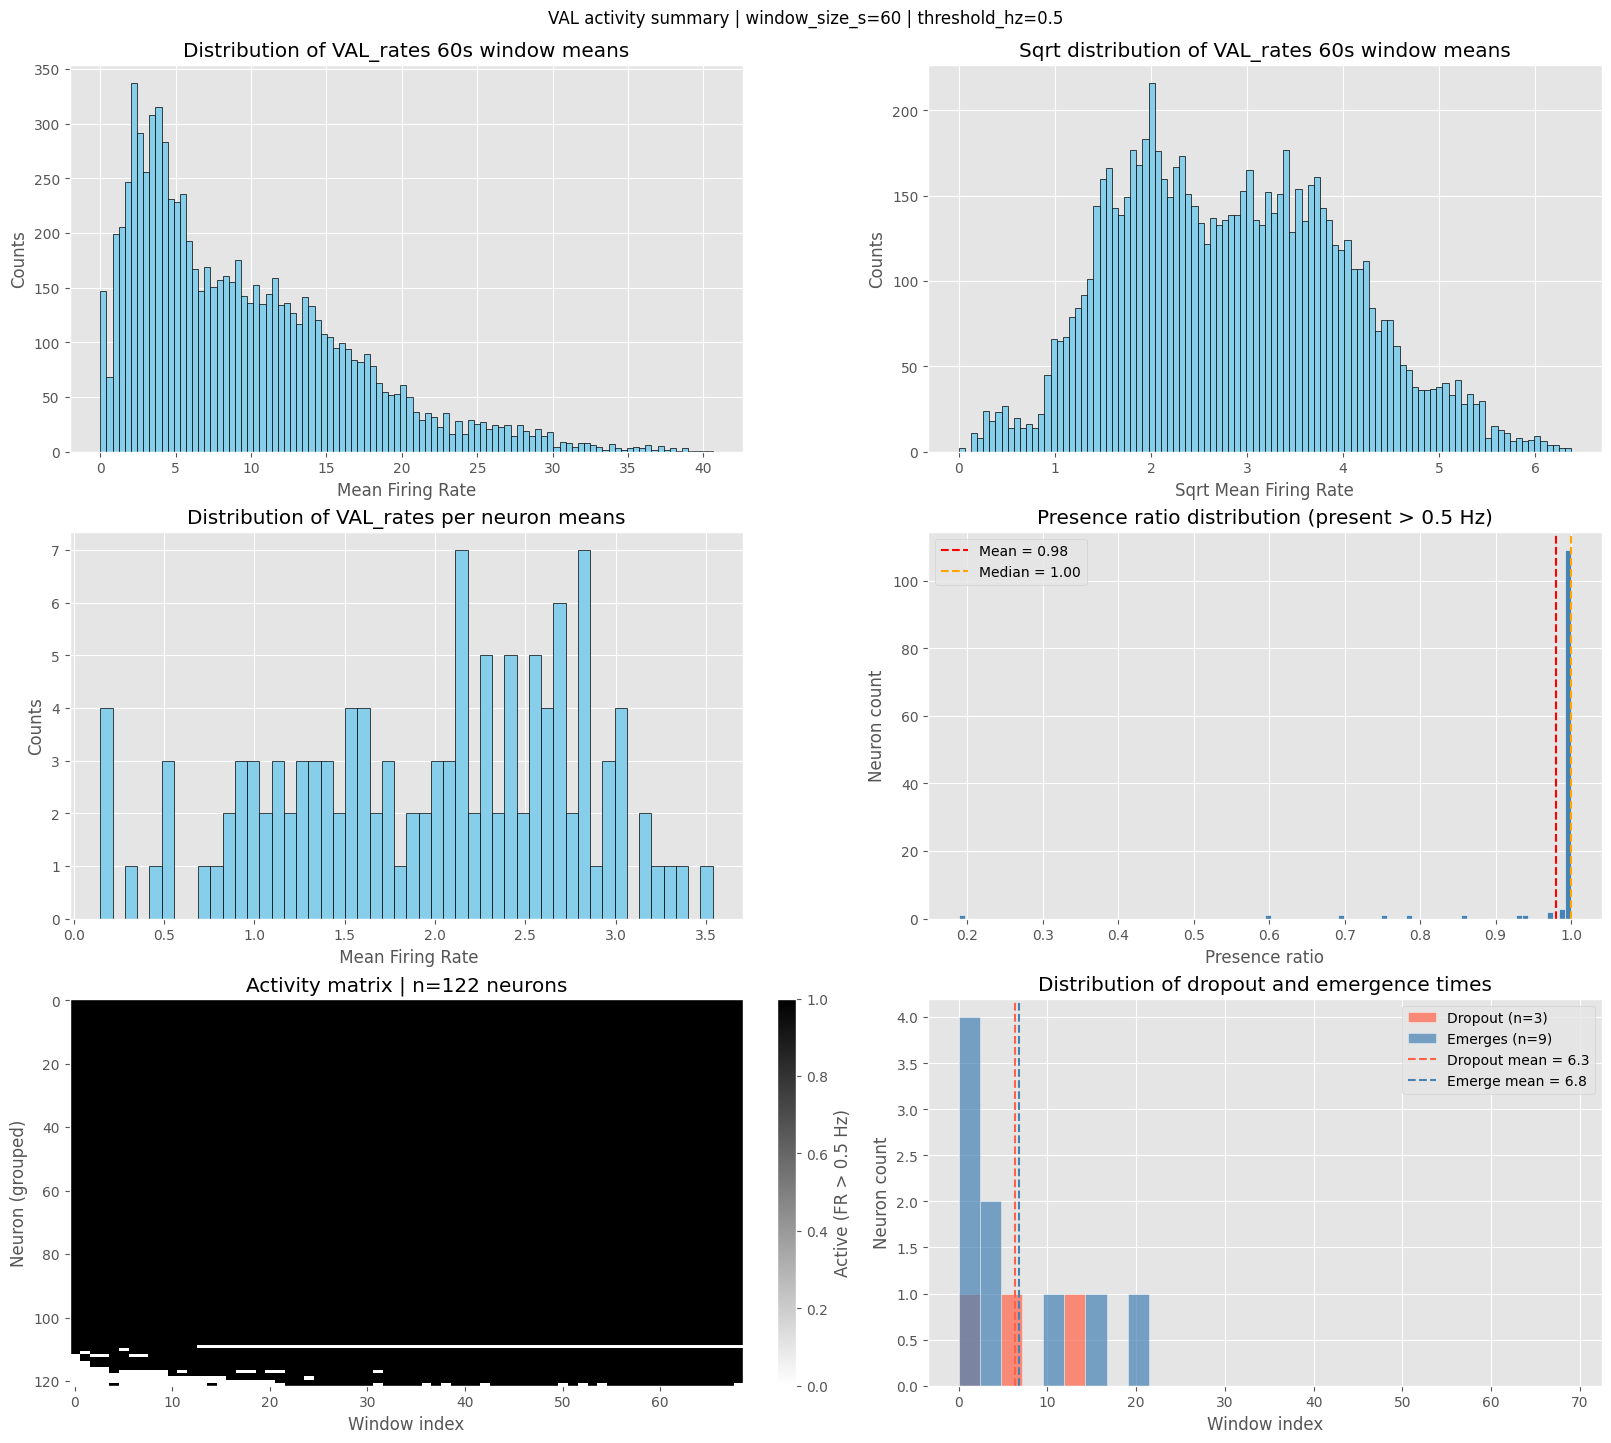

In [82]:
fig, axes = plot_area_activity_figure(prep_df, area='VAL', window_size_s=60, threshold_hz=0.5)

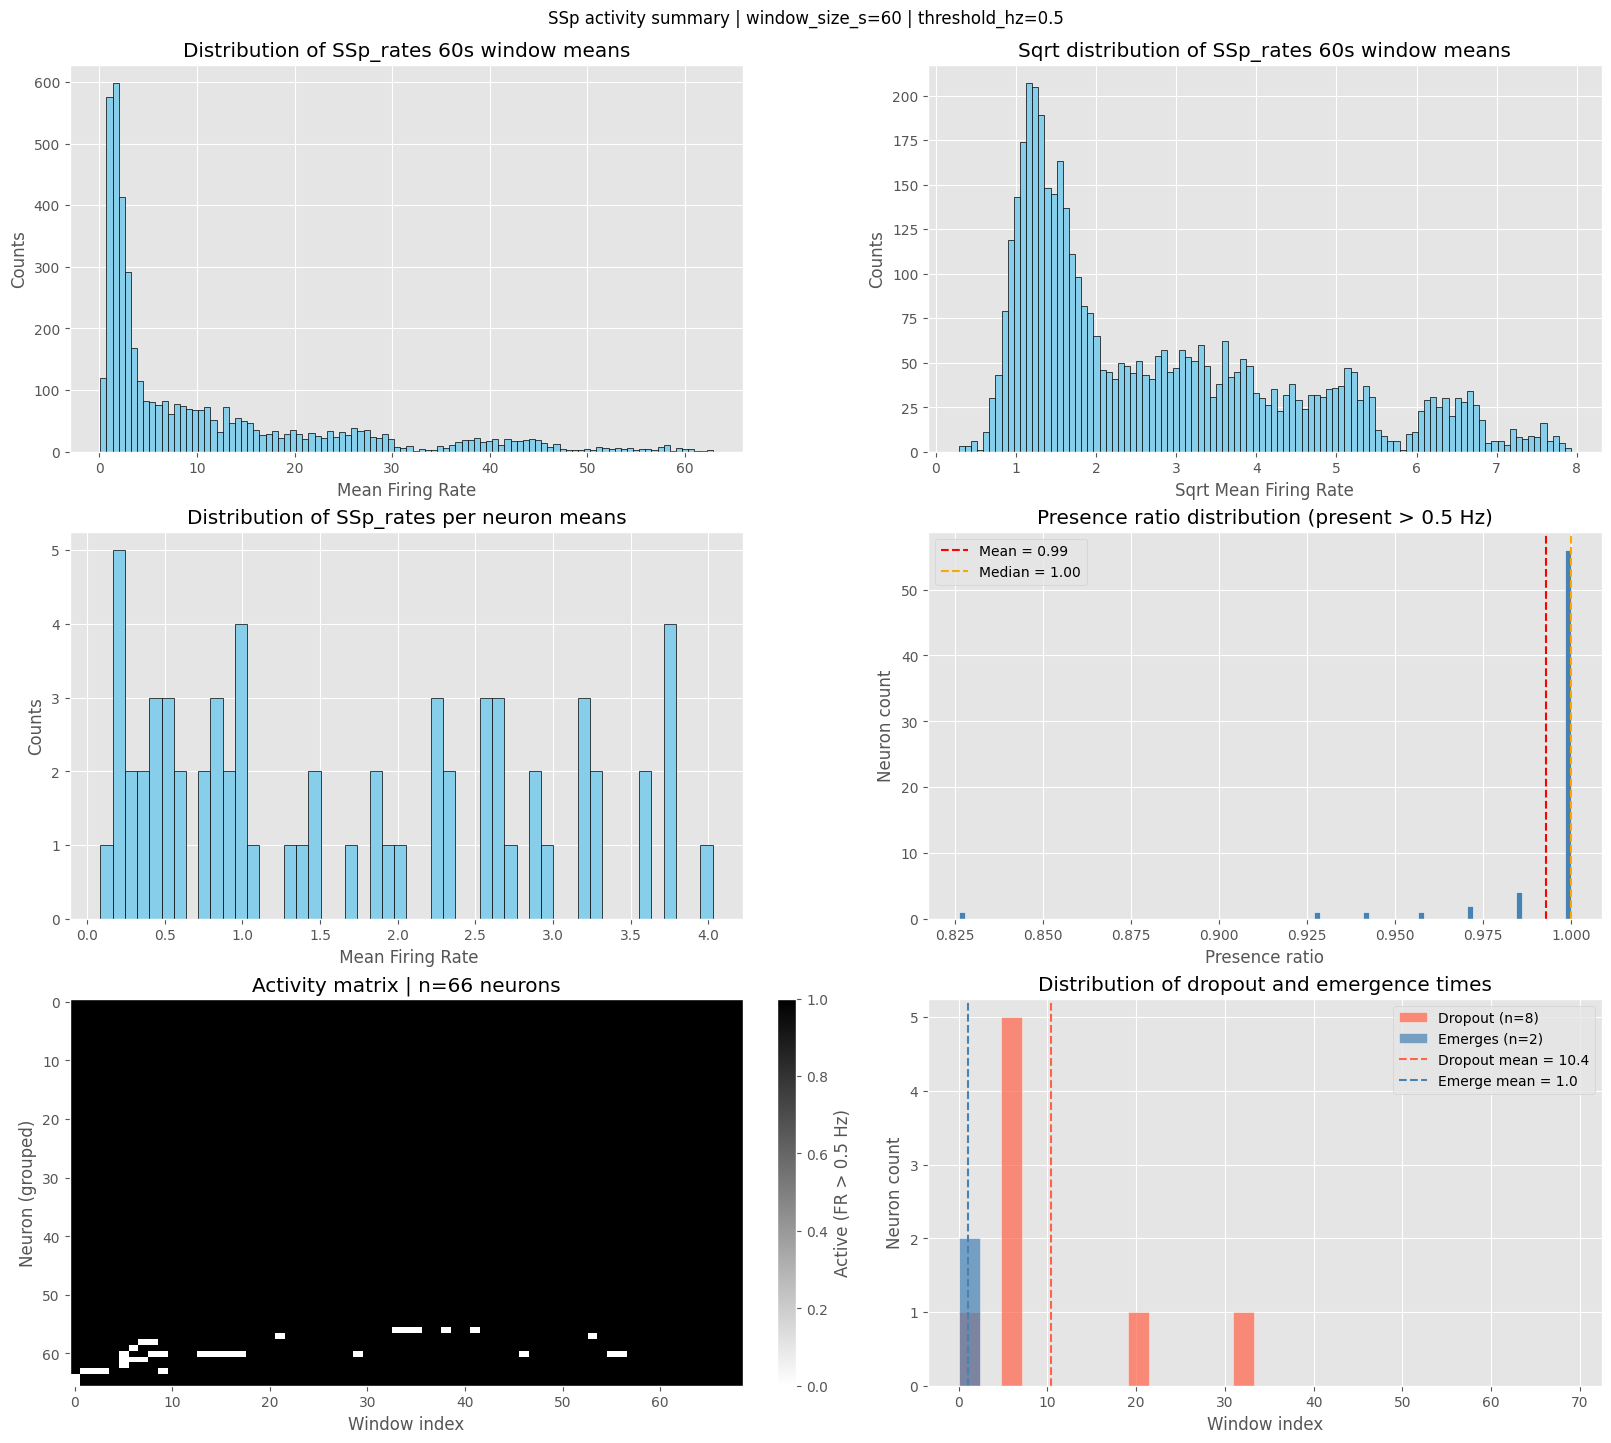

In [83]:
fig, axes = plot_area_activity_figure(prep_df, area='SSp', window_size_s=60, threshold_hz=0.5)

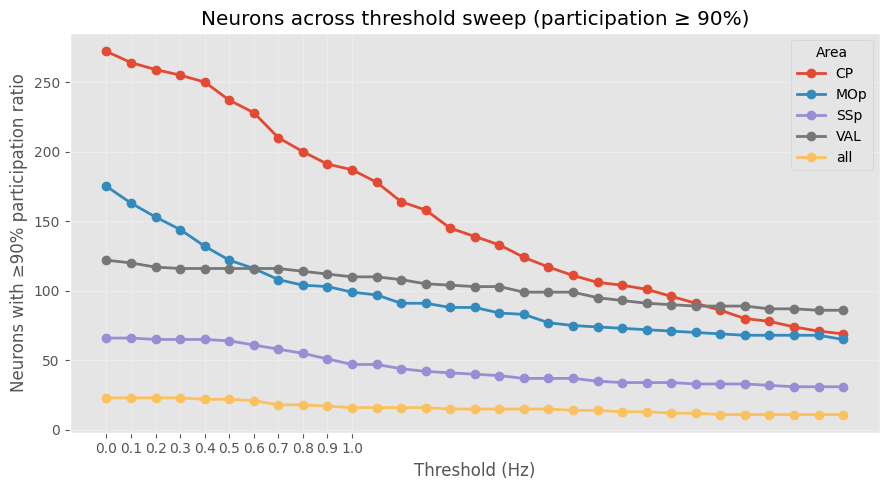

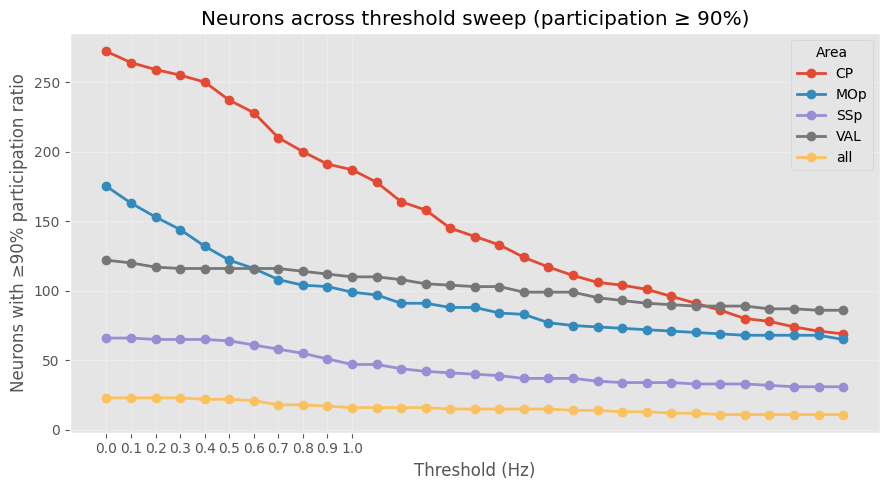

In [97]:
thresholds = np.arange(0.0, 3.01, 0.1)
areas = get_rate_areas(prep_df)

# Compute with 90% participation threshold
sweep_df = compute_full_participation_sweep(
    prep_df,
    areas=areas,
    window_size_s=30,
    thresholds=thresholds,
    participation_ratio_threshold=0.9,  # 90% participation
)

fig, ax = plot_full_participation_sweep(sweep_df)
fig